In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

from jazzy.core import get_charges_from_kallisto_molecule
from jazzy.core import get_covalent_atom_idxs
from jazzy.core import kallisto_molecule_from_rdkit_molecule
from jazzy.core import rdkit_molecule_from_smiles
from jazzy.core import calculate_polar_strength_map

In [2]:
df = pd.read_csv("../data/acceptor_Strength/kenny_pkbhx.txt",sep=" ")
smiles = df["#SMILES"].to_list()
pKBHX = df.pKBHX.to_numpy()

max_sa = []
pkbhx = []
for smile, pkb in zip(smiles, pKBHX):
    rdkit_mol = rdkit_molecule_from_smiles(smile, minimisation_method="MMFF94")
    if rdkit_mol != None:
        kallisto_mol = kallisto_molecule_from_rdkit_molecule(rdkit_mol)
        atoms_and_nbrs = get_covalent_atom_idxs(rdkit_mol)
        kmol = kallisto_molecule_from_rdkit_molecule(rdkit_mol)
        charges = get_charges_from_kallisto_molecule(kmol, charge=0)
        atomic_map = calculate_polar_strength_map(
        rdkit_mol, kallisto_mol, atoms_and_nbrs, charges, m=(0.9998812365145566, 17.39993373022188)
        )
        max_sa.append(np.max([atomic_map[x]["sa"] for x in atomic_map.keys()]))
        pkbhx.append(pkb)
        

Jazzy ERROR: [10:14:08] The RDKit embedding has failed for the molecule: C1C2CC3CC1CC(C2)C34C5(C6CC7CC(C6)CC5C7)OO4
[10:14:12] UFFTYPER: Unrecognized charge state for atom: 2
[10:14:14] UFFTYPER: Unrecognized charge state for atom: 1


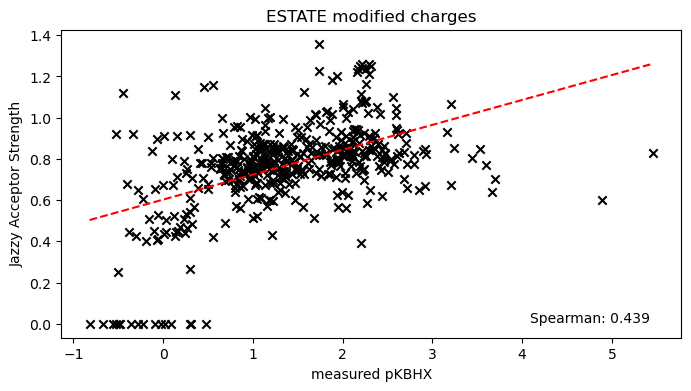

In [3]:
def plot_with_linregress(ax, x, y, minx=None, maxx=None, marker="x", color="black"):
    # Scatter plot
    ax.scatter(x, y, marker=marker, color=color)

    # Determine min and max x values for regression line if not provided
    if minx is None:
        minx = np.min(x)
    if maxx is None:
        maxx = np.max(x)

    # Perform linear regression with specified minx and maxx
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    x_line = np.array([minx, maxx])
    y_line = slope * x_line + intercept

    # Plot the regression line
    ax.plot(x_line, y_line, linestyle="--", color="red")

fig, ax = plt.subplots(1,1,figsize=(8,4))
plot_with_linregress(ax, pkbhx, max_sa)

ax.text(0.95,0.05,"Spearman: {:.3f}".format(stats.spearmanr(max_sa, pkbhx, )[0]), transform=ax.transAxes, horizontalalignment="right")
ax.set_title("ESTATE modified charges")
ax.set_xlabel("measured pKBHX")
ax.set_ylabel("Jazzy Acceptor Strength")
plt.show()